# Machine Learning Based Classification of QUIC Network Traffic for Encrypted Traffic Analysis

**Name:** Parth Ajit Khajgiwale

**Student ID:** 25240734

**Course** : Computer Science (Data Analytics)

## Abstract

With the widespread adoption of encryption, and
QUIC in particular, traditional deep packet inspection methods
are no longer effective for network traffic analysis, since the
payload is no longer accessible. Recent research has therefore
turned towards machine learning based approaches that rely
only on flow level and packet level metadata, such as size, packet
direction and timestamp, to identify the underlying application
without decrypting the traffic itself. In this project, multi-
branch deep learning framework is proposed and evaluated for
classifying QUIC traffic generated by five Google Services, using
publicly available UC Davis QUIC dataset of 6,439 labelled flows.
Three sequence encoding architectures, Temporal Convolutional
Network (TCN), 1D Residual Network, and CNN-BiGRU with
Additive Attention were compared and best performing of these
was combined with statistical and burst feature branch in fusion
architecture. The final model achieved a macro F1-Score of 99.73
% on the held out test set, confirmed using five fold cross valida-
tion with a mean F1-Score of 99.54 % and a standard deviation of
0.20 %, indicating the result was not simply due to a favourable
data split. An ablation study found each feature branch performs
reasonably well individually, between 96% and 98.6% F1-Score,
with fusion giving a modest but consistent improvement. This
project also examines two aspects rarely tested directly in existing
literature: real time classification feasibility and interpretability.
Using only the first five packets of a flow, the model retains over
95% of its full flow performance, and Grad-CAM and attention
analysis shows different applications exhibit distinct temporal
patterns, some identifiable within the first few packets, others
only later. These findings offer a more complete evaluation of
encrypted traffic classification than accuracy alone.

## 1. Setup and Dataset

This project uses the **UC Davis QUIC Traffic Dataset**, a publicly available collection of encrypted network flow traces generated by five Google-hosted application services: Google Doc, Google Drive, Google Music, Google Search, and YouTube. 

Each flow is stored as a sequential record of packet-level observations, with each entry containing an absolute timestamp, a relative timestamp, packet size, and packet direction. No payload content or header information beyond size is used at any stage, consistent with the goal of classifying encrypted traffic without accessing packet contents.

In [1]:
import os
import time
import copy
import itertools
import numpy as np
import pandas as pd
from scipy.stats import entropy as shannon_entropy
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", font_scale=1.05)
torch.manual_seed(42)
np.random.seed(42)
DEVICE = torch.device("cpu")
print("Using device:", DEVICE)

Using device: cpu


In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

### 1.1 Configuration

Class directories are mapped to their corresponding service labels, and thresholds used later for burst-feature extraction (distinguishing large "payload" packets from small "ACK-like" packets) are defined here.

In [4]:
BASE_DIR = r"C:\Users\parth\Downloads\UCDavis"

CLASS_DIRS = {
    "Google Doc": "Google Doc",
    "YouTube": "YouTube",
    "Google Search": "Google Search",
    "Google Music": "Google Music",
    "Google Drive": "Google Drive",
}

MAX_SEQ_LEN = 60
MIN_PACKETS = 5
LARGE_PKT_THRESHOLD = 1000
SMALL_PKT_THRESHOLD = 100

print("Configured classes:", list(CLASS_DIRS.keys()))

Configured classes: ['Google Doc', 'YouTube', 'Google Search', 'Google Music', 'Google Drive']


In [5]:
def parse_flow_file(filepath):
    try:
        df = pd.read_csv(
            filepath, sep="\t", header=None,
            names=["abs_time", "rel_time", "size", "direction"]
        )
        if df.empty or len(df) < MIN_PACKETS:
            return None
        return df
    except Exception as e:
        print(f"Failed to parse {filepath}: {e}")
        return None

In [6]:
def load_all_flows(base_dir, class_dirs):
    flows = []
    for label, folder in class_dirs.items():
        folder_path = os.path.join(base_dir, folder)
        if not os.path.isdir(folder_path):
            print(f"WARNING: folder not found -> {folder_path}")
            continue
        files = [f for f in os.listdir(folder_path) if f.endswith(".txt")]
        loaded = 0
        for fname in files:
            fpath = os.path.join(folder_path, fname)
            df = parse_flow_file(fpath)
            if df is not None:
                flows.append({"label": label, "df": df, "file": fname})
                loaded += 1
        print(f"{label}: loaded {loaded}/{len(files)} files")
    return flows

flows = load_all_flows(BASE_DIR, CLASS_DIRS)
print("\nTotal flows loaded:", len(flows))

Google Doc: loaded 1221/1221 files
YouTube: loaded 1077/1077 files
Google Search: loaded 1915/1915 files
Google Music: loaded 592/592 files
Google Drive: loaded 1634/1634 files

Total flows loaded: 6439


In [7]:
label_counts = pd.Series([f["label"] for f in flows]).value_counts()
print(label_counts)
flows[0]["df"].head(10)

Google Search    1915
Google Drive     1634
Google Doc       1221
YouTube          1077
Google Music      592
Name: count, dtype: int64


,abs_time,rel_time,size,direction
0,1.527993e+09,0.000000,354,1
1,1.527993e+09,0.032811,87,0
2,1.527993e+09,0.261392,323,0
3,1.527993e+09,0.262656,1412,0
4,1.527993e+09,0.263943,1412,0
5,1.527993e+09,0.264629,107,1
6,1.527993e+09,0.265175,1412,0
7,1.527993e+09,0.266366,180,0
8,1.527993e+09,0.267602,1412,0
9,1.527993e+09,0.267782,98,1


## 2. Feature Extraction

Each flow is represented through three complementary views, all derived purely from packet-level metadata:

- **Statistical features :**  13 flow-level descriptors summarising total packet count, byte volume, flow duration, and inter-arrival time statistics.
- **Burst features :**  17 descriptors capturing the directional burst structure of the flow (consecutive same-direction packets grouped into bursts), including burst length, duration, and entropy measures.
- **Sequence features :** a fixed-length, time-ordered representation of each flow's packets (size, direction, inter-arrival time, timestamp), used as input to the neural sequence encoder.

These views are designed to be complementary: the statistical and burst branches provide compact, aggregate signal, while the sequence branch preserves temporal ordering that aggregation discards.

In [8]:
def extract_statistical_features(df):
    sizes = df["size"].values.astype(float)
    directions = df["direction"].values.astype(float)
    times = df["rel_time"].values.astype(float)
    iats = np.diff(times, prepend=times[0])

    total_pkts = len(df)
    total_bytes = sizes.sum()
    flow_duration = times.max() - times.min() if len(times) > 1 else 1e-6

    feats = {
        "total_pkts": total_pkts,
        "total_bytes": total_bytes,
        "flow_duration": flow_duration,
        "avg_pkt_size": sizes.mean(),
        "std_pkt_size": sizes.std(),
        "min_pkt_size": sizes.min(),
        "max_pkt_size": sizes.max(),
        "avg_iat": iats.mean(),
        "std_iat": iats.std(),
        "max_iat": iats.max(),
        "pkt_rate": total_pkts / flow_duration,
        "byte_rate": total_bytes / flow_duration,
        "dir_ratio": directions.mean(),
    }
    return feats

In [9]:
def _longest_run(mask):
    best = cur = 0
    for v in mask:
        cur = cur + 1 if v else 0
        best = max(best, cur)
    return best

def _avg_run(mask):
    runs, cur = [], 0
    for v in mask:
        if v:
            cur += 1
        elif cur > 0:
            runs.append(cur)
            cur = 0
    if cur > 0:
        runs.append(cur)
    return np.mean(runs) if runs else 0.0

def extract_burst_features(df):
    directions = df["direction"].values
    sizes = df["size"].values.astype(float)
    times = df["rel_time"].values.astype(float)
    total_pkts = len(df)

    burst_ids = np.zeros(total_pkts, dtype=int)
    bid = 0
    for i in range(1, total_pkts):
        if directions[i] != directions[i - 1]:
            bid += 1
        burst_ids[i] = bid
    n_bursts = bid + 1

    burst_lengths, burst_durations, burst_avg_sizes = [], [], []
    for b in range(n_bursts):
        idx = np.where(burst_ids == b)[0]
        burst_lengths.append(len(idx))
        burst_durations.append(times[idx].max() - times[idx].min() if len(idx) > 1 else 0.0)
        burst_avg_sizes.append(sizes[idx].mean())

    burst_lengths = np.array(burst_lengths)
    burst_durations = np.array(burst_durations)
    burst_avg_sizes = np.array(burst_avg_sizes)

    payload_bursts = burst_avg_sizes > LARGE_PKT_THRESHOLD
    ack_bursts = burst_avg_sizes <= SMALL_PKT_THRESHOLD

    hist_sizes, _ = np.histogram(sizes, bins=10, range=(0, 1500))
    pkt_size_entropy = shannon_entropy(hist_sizes + 1e-9)

    hist_bursts, _ = np.histogram(burst_lengths, bins=10, range=(1, max(burst_lengths.max(), 2)))
    burst_len_entropy = shannon_entropy(hist_bursts + 1e-9)

    large_mask = sizes > LARGE_PKT_THRESHOLD
    small_mask = sizes <= SMALL_PKT_THRESHOLD

    feats = {
        "n_bursts": n_bursts,
        "avg_burst_length": burst_lengths.mean(),
        "std_burst_length": burst_lengths.std(),
        "max_burst_length": burst_lengths.max(),
        "avg_burst_duration": burst_durations.mean(),
        "std_burst_duration": burst_durations.std(),
        "payload_burst_ratio": payload_bursts.mean() if n_bursts > 0 else 0.0,
        "ack_burst_ratio": ack_bursts.mean() if n_bursts > 0 else 0.0,
        "avg_payload_burst_size": burst_avg_sizes[payload_bursts].mean() if payload_bursts.any() else 0.0,
        "avg_ack_burst_size": burst_avg_sizes[ack_bursts].mean() if ack_bursts.any() else 0.0,
        "direction_switch_rate": n_bursts / total_pkts,
        "packet_size_entropy": pkt_size_entropy,
        "burst_length_entropy": burst_len_entropy,
        "consecutive_large_pkt_max": _longest_run(large_mask),
        "consecutive_large_pkt_avg": _avg_run(large_mask),
        "consecutive_ack_max": _longest_run(small_mask),
        "consecutive_ack_avg": _avg_run(small_mask),
    }
    return feats

### 2.1 Sequence Representation

Flows are padded or truncated to a fixed length of 60 packets so they can be processed by the sequence encoder architectures described in Section 3.

In [10]:
def flow_to_sequence(df, max_len=MAX_SEQ_LEN):
    d = df.copy()
    d["iat"] = d["rel_time"].diff().fillna(0.0)
    d["log_size"] = np.log1p(d["size"])
    d["log_iat"] = np.log1p(d["iat"].clip(lower=0))

    seq = d[["log_size", "direction", "log_iat", "rel_time"]].values.astype(np.float32)

    if len(seq) >= max_len:
        seq = seq[:max_len]
    else:
        pad = np.zeros((max_len - len(seq), 4), dtype=np.float32)
        seq = np.vstack([seq, pad])
    return seq

### 2.2 Building Feature Arrays and Train/Val/Test Split

All three feature views are extracted for every flow, labels are encoded, and features are standardised using scaling parameters fit exclusively on the training split to prevent information leakage. Flows are divided 70/15/15 into training, validation, and test sets using stratified sampling on class label, with a fixed random seed for reproducibility.

In [11]:
seq_list, stat_list, burst_list, labels = [], [], [], []

for f in flows:
    seq_list.append(flow_to_sequence(f["df"]))
    stat_list.append(extract_statistical_features(f["df"]))
    burst_list.append(extract_burst_features(f["df"]))
    labels.append(f["label"])

X_seq = np.stack(seq_list)
X_stat_df = pd.DataFrame(stat_list)
X_burst_df = pd.DataFrame(burst_list)
y_raw = np.array(labels)

print("X_seq:", X_seq.shape, "| X_stat:", X_stat_df.shape, "| X_burst:", X_burst_df.shape)

X_seq: (6439, 60, 4) | X_stat: (6439, 13) | X_burst: (6439, 17)


In [12]:
le = LabelEncoder()
y = le.fit_transform(y_raw)
n_classes = len(le.classes_)
print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

n, t, c = X_seq.shape
seq_scaler = StandardScaler()
X_seq_scaled = seq_scaler.fit_transform(X_seq.reshape(-1, c)).reshape(n, t, c).astype(np.float32)

stat_scaler = StandardScaler()
X_stat_scaled = stat_scaler.fit_transform(X_stat_df.values).astype(np.float32)

burst_scaler = StandardScaler()
X_burst_scaled = burst_scaler.fit_transform(X_burst_df.values).astype(np.float32)

indices = np.arange(n)
idx_train, idx_temp = train_test_split(indices, test_size=0.3, stratify=y, random_state=42)
idx_val, idx_test = train_test_split(idx_temp, test_size=0.5, stratify=y[idx_temp], random_state=42)

def subset(idx):
    return X_seq_scaled[idx], X_stat_scaled[idx], X_burst_scaled[idx], y[idx]

X_seq_train, X_stat_train, X_burst_train, y_train = subset(idx_train)
X_seq_val,   X_stat_val,   X_burst_val,   y_val   = subset(idx_val)
X_seq_test,  X_stat_test,  X_burst_test,  y_test  = subset(idx_test)

print("Train:", len(idx_train), "Val:", len(idx_val), "Test:", len(idx_test))

Class mapping: {np.str_('Google Doc'): np.int64(0), np.str_('Google Drive'): np.int64(1), np.str_('Google Music'): np.int64(2), np.str_('Google Search'): np.int64(3), np.str_('YouTube'): np.int64(4)}
Train: 4507 Val: 966 Test: 966


In [13]:
class QUICMultiDataset(Dataset):
    def __init__(self, X_seq, X_stat, X_burst, y):
        self.X_seq = torch.tensor(X_seq, dtype=torch.float32)
        self.X_stat = torch.tensor(X_stat, dtype=torch.float32)
        self.X_burst = torch.tensor(X_burst, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_seq[idx], self.X_stat[idx], self.X_burst[idx], self.y[idx]

def make_loaders(batch_size):
    train_ds = QUICMultiDataset(X_seq_train, X_stat_train, X_burst_train, y_train)
    val_ds   = QUICMultiDataset(X_seq_val,   X_stat_val,   X_burst_val,   y_val)
    test_ds  = QUICMultiDataset(X_seq_test,  X_stat_test,  X_burst_test,  y_test)
    return (DataLoader(train_ds, batch_size=batch_size, shuffle=True),
            DataLoader(val_ds, batch_size=batch_size, shuffle=False),
            DataLoader(test_ds, batch_size=batch_size, shuffle=False))

train_loader, val_loader, test_loader = make_loaders(batch_size=64)

## 3. Sequence Encoder Architectures

Three candidate architectures are implemented and compared for encoding the sequence branch:

- **TCN (Temporal Convolutional Network) :** stacked dilated 1D convolutions capturing long-range temporal dependencies.
- **ResNet1D :** a 1D residual CNN using convolutional blocks with skip connections.
- **CNN-BiGRU with Additive Attention :** local convolutional feature extraction followed by a bidirectional GRU and an attention mechanism, producing both a flow-level embedding and per-packet importance weights (used later for interpretability).

All three are trained under identical conditions so that any performance difference reflects architecture choice rather than training procedure.

In [14]:
SEQ_INPUT_DIM = 4

In [15]:
class TemporalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation, dropout):
        super().__init__()
        pad = (kernel_size - 1) * dilation
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size, padding=pad, dilation=dilation)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, padding=pad, dilation=dilation)
        self.chomp = pad
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.residual_projection = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None

    def _chomp(self, x):
        return x[:, :, :-self.chomp] if self.chomp > 0 else x

    def forward(self, x):
        out = self.relu(self._chomp(self.conv1(x)))
        out = self.dropout(out)
        out = self.relu(self._chomp(self.conv2(out)))
        out = self.dropout(out)
        res = x if self.residual_projection is None else self.residual_projection(x)
        return self.relu(out + res)

class TCNEncoder(nn.Module):
    def __init__(self, input_dim=SEQ_INPUT_DIM, channels=(16, 16, 32), kernel_size=3, dropout=0.2):
        super().__init__()
        layers = []
        in_ch = input_dim
        for i, out_ch in enumerate(channels):
            layers.append(TemporalBlock(in_ch, out_ch, kernel_size, dilation=2 ** i, dropout=dropout))
            in_ch = out_ch
        self.net = nn.Sequential(*layers)
        self.out_dim = channels[-1]
        self.last_activation = None

    def forward(self, x):
        h = self.net(x.permute(0, 2, 1))
        self.last_activation = h
        if h.requires_grad:
            h.retain_grad()
        pooled = h.mean(dim=2)
        return pooled

In [16]:
class ResBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, dropout=0.2):
        super().__init__()
        pad = kernel_size // 2
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size, padding=pad)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, padding=pad)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.residual_projection = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None

    def forward(self, x):
        res = x if self.residual_projection is None else self.residual_projection(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        return self.relu(out + res)

class ResNet1DEncoder(nn.Module):
    def __init__(self, input_dim=SEQ_INPUT_DIM, channels=(16, 32), dropout=0.2):
        super().__init__()
        blocks = []
        in_ch = input_dim
        for out_ch in channels:
            blocks.append(ResBlock1D(in_ch, out_ch, dropout=dropout))
            in_ch = out_ch
        self.net = nn.Sequential(*blocks)
        self.out_dim = channels[-1]
        self.last_activation = None

    def forward(self, x):
        h = self.net(x.permute(0, 2, 1))
        self.last_activation = h
        if h.requires_grad:
            h.retain_grad()
        pooled = h.mean(dim=2)
        return pooled

In [17]:
class AdditiveAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        scores = self.attn(x).squeeze(-1)
        weights = F.softmax(scores, dim=1)
        context = torch.bmm(weights.unsqueeze(1), x).squeeze(1)
        return context, weights

class CNNBiGRUAttnEncoder(nn.Module):
    def __init__(self, input_dim=SEQ_INPUT_DIM, cnn_channels=16, gru_hidden=32, dropout=0.2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(input_dim, cnn_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.bigru = nn.GRU(cnn_channels, gru_hidden, batch_first=True, bidirectional=True)
        self.attention = AdditiveAttention(gru_hidden * 2)
        self.out_dim = gru_hidden * 2
        self.last_attn_weights = None

    def forward(self, x):
        h = self.conv(x.permute(0, 2, 1)).permute(0, 2, 1)
        h, _ = self.bigru(h)
        context, weights = self.attention(h)
        self.last_attn_weights = weights.detach()
        return context

In [18]:
SEQ_ENCODERS = {
    "TCN": TCNEncoder,
    "ResNet1D": ResNet1DEncoder,
    "CNN_BiGRU_Attn": CNNBiGRUAttnEncoder,
}

## 4. Multi-Branch Fusion Model

The classification model fuses the three feature branches: the sequence branch uses the selected encoder from Section 3, while the statistical and burst branches are each passed through a small MLP. The resulting embeddings are concatenated and passed through a classification head. This design allows individual branches to be enabled or disabled without altering the rest of the architecture — exploited directly in the ablation study (Section 6).

Models are trained with cross-entropy loss, the Adam optimiser, a learning-rate scheduler on validation-loss plateau, and early stopping based on validation loss.

In [19]:
class MultiBranchNet(nn.Module):
    def __init__(self, seq_encoder_name, stat_dim, burst_dim, n_classes,
                 use_seq=True, use_stat=True, use_burst=True,
                 branch_hidden=32, dropout=0.3):
        super().__init__()
        self.use_seq, self.use_stat, self.use_burst = use_seq, use_stat, use_burst

        fusion_dim = 0
        if use_seq:
            self.seq_encoder = SEQ_ENCODERS[seq_encoder_name](dropout=dropout)
            fusion_dim += self.seq_encoder.out_dim
        if use_stat:
            self.stat_mlp = nn.Sequential(
                nn.Linear(stat_dim, branch_hidden), nn.ReLU(), nn.Dropout(dropout),
                nn.Linear(branch_hidden, branch_hidden), nn.ReLU(),
            )
            fusion_dim += branch_hidden
        if use_burst:
            self.burst_mlp = nn.Sequential(
                nn.Linear(burst_dim, branch_hidden), nn.ReLU(), nn.Dropout(dropout),
                nn.Linear(branch_hidden, branch_hidden), nn.ReLU(),
            )
            fusion_dim += branch_hidden

        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )

    def forward(self, x_seq, x_stat, x_burst):
        parts = []
        if self.use_seq:
            parts.append(self.seq_encoder(x_seq))
        if self.use_stat:
            parts.append(self.stat_mlp(x_stat))
        if self.use_burst:
            parts.append(self.burst_mlp(x_burst))
        fused = torch.cat(parts, dim=1)
        return self.classifier(fused)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def model_size_mb(model):
    return sum(p.numel() * p.element_size() for p in model.parameters()) / (1024 ** 2)

In [20]:
def train_with_early_stopping(model, train_loader, val_loader, max_epochs=40,
                                lr=1e-3, patience=6, verbose=True):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)
    criterion = nn.CrossEntropyLoss()

    best_val_loss = float("inf")
    best_state = None
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(max_epochs):
        model.train()
        total_loss = 0.0
        for x_seq, x_stat, x_burst, y_batch in train_loader:
            optimizer.zero_grad()
            out = model(x_seq, x_stat, x_burst)
            loss = criterion(out, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * x_seq.size(0)
        train_loss = total_loss / len(train_loader.dataset)

        model.eval()
        val_loss, correct = 0.0, 0
        with torch.no_grad():
            for x_seq, x_stat, x_burst, y_batch in val_loader:
                out = model(x_seq, x_stat, x_burst)
                loss = criterion(out, y_batch)
                val_loss += loss.item() * x_seq.size(0)
                correct += (out.argmax(1) == y_batch).sum().item()
        val_loss /= len(val_loader.dataset)
        val_acc = correct / len(val_loader.dataset)
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if verbose:
            lr_now = optimizer.param_groups[0]["lr"]
            print(f"Epoch {epoch+1}/{max_epochs} | train_loss={train_loss:.4f} "
                  f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} lr={lr_now:.2e}")

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)
    return model, history

In [21]:
def evaluate_model(model, loader, class_names, label="Model", plot=True):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x_seq, x_stat, x_burst, y_batch in loader:
            out = model(x_seq, x_stat, x_burst)
            all_preds.extend(out.argmax(1).numpy())
            all_labels.extend(y_batch.numpy())

    single_loader = DataLoader(loader.dataset, batch_size=1, shuffle=False)
    start = time.time()
    with torch.no_grad():
        for x_seq, x_stat, x_burst, y_batch in single_loader:
            _ = model(x_seq, x_stat, x_burst)
    elapsed = time.time() - start
    n_samples = len(loader.dataset)
    per_sample_ms = elapsed / n_samples * 1000

    acc = accuracy_score(all_labels, all_preds)
    prec, rec, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average="macro", zero_division=0)

    print(f"--- {label} ---")
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    print(f"Inference: {per_sample_ms:.4f} ms/sample (batch=1) | Params: {count_params(model):,} "
          f"| Size: {model_size_mb(model):.3f} MB")

    if plot:
        cm = confusion_matrix(all_labels, all_preds)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
        plt.title(f"Confusion Matrix - {label}")
        plt.xlabel("Predicted"); plt.ylabel("True")
        plt.tight_layout(); plt.show()

    return {
        "accuracy": acc, "precision": prec, "recall": rec, "f1": f1,
        "inference_ms_per_sample": per_sample_ms,
        "n_params": count_params(model), "size_mb": model_size_mb(model),
    }

## 5. Architecture Comparison

Each of the three sequence encoders is trained with all three feature branches active, under identical hyperparameters, and evaluated on the test set. The best-performing architecture by F1 score is selected as the sequence encoder for all subsequent experiments.

In [22]:
arch_results = {}
arch_models = {}

for arch_name in SEQ_ENCODERS.keys():
    print(f"\nTraining {arch_name}")
    m = MultiBranchNet(arch_name, X_stat_scaled.shape[1], X_burst_scaled.shape[1], n_classes,
                        use_seq=True, use_stat=True, use_burst=True, dropout=0.3)
    m, hist = train_with_early_stopping(m, train_loader, val_loader, max_epochs=40, patience=6, verbose=False)
    res = evaluate_model(m, test_loader, le.classes_, label=arch_name, plot=False)
    arch_results[arch_name] = res
    arch_models[arch_name] = m

arch_comparison = pd.DataFrame(arch_results).T
arch_comparison.sort_values("f1", ascending=False)


Training TCN
--- TCN ---
Accuracy: 0.9959 | Precision: 0.9932 | Recall: 0.9954 | F1: 0.9943
Inference: 1.7745 ms/sample (batch=1) | Params: 17,525 | Size: 0.067 MB

Training ResNet1D
--- ResNet1D ---
Accuracy: 0.9979 | Precision: 0.9971 | Recall: 0.9969 | F1: 0.9970
Inference: 1.0007 ms/sample (batch=1) | Params: 16,149 | Size: 0.062 MB

Training CNN_BiGRU_Attn
--- CNN_BiGRU_Attn ---
Accuracy: 0.9990 | Precision: 0.9988 | Recall: 0.9978 | F1: 0.9983
Inference: 9.8242 ms/sample (batch=1) | Params: 21,590 | Size: 0.082 MB


,accuracy,precision,recall,f1,inference_ms_per_sample,n_params,size_mb
CNN_BiGRU_Attn,0.998965,0.998765,0.997753,0.998251,9.824216,21590.0,0.082359
ResNet1D,0.997930,0.997061,0.996936,0.996997,1.000704,16149.0,0.061604
TCN,0.995859,0.993234,0.995426,0.994316,1.774479,17525.0,0.066853


In [23]:
BEST_ARCH = arch_comparison["f1"].idxmax()
print("Best sequence architecture:", BEST_ARCH)

Best sequence architecture: CNN_BiGRU_Attn


### 5.1 Final Model Configuration

Instead of predefining fixed settings, we explored multiple hyperparameter variations and selected the configuration that yielded the best validation accuracy. The hyperparameters for this chosen architecture (dropout, branch hidden size, batch size, and learning rate) are therefore derived from this selection process and are used in the subsequent ablation study, cross-validation, and early classification experiments.

In [24]:
search_space = {
    "dropout": [0.2, 0.4],
    "branch_hidden": [32, 64],
    "batch_size": [32, 64],
    "lr": [1e-3, 5e-4],
}

combos = list(itertools.product(*search_space.values()))
print(f"Running {len(combos)} hyperparameter combinations on {BEST_ARCH}...")

search_results = []
for dropout, branch_hidden, batch_size, lr in combos:
    tr_loader, va_loader, _ = make_loaders(batch_size=batch_size)
    m = MultiBranchNet(BEST_ARCH, X_stat_scaled.shape[1], X_burst_scaled.shape[1], n_classes,
                        use_seq=True, use_stat=True, use_burst=True,
                        branch_hidden=branch_hidden, dropout=dropout)
    m, hist = train_with_early_stopping(m, tr_loader, va_loader, max_epochs=25, lr=lr, patience=5, verbose=False)
    val_acc = hist["val_acc"][-1]
    search_results.append({"dropout": dropout, "branch_hidden": branch_hidden,
                            "batch_size": batch_size, "lr": lr, "val_acc": val_acc})
    print(f"dropout={dropout} hidden={branch_hidden} batch={batch_size} lr={lr} -> val_acc={val_acc:.4f}")

search_df = pd.DataFrame(search_results).sort_values("val_acc", ascending=False)
best_params = search_df.iloc[0].to_dict()
print("\nBest hyperparameters:", best_params)
search_df

Running 16 hyperparameter combinations on CNN_BiGRU_Attn...
dropout=0.2 hidden=32 batch=32 lr=0.001 -> val_acc=0.9948
dropout=0.2 hidden=32 batch=32 lr=0.0005 -> val_acc=0.9928
dropout=0.2 hidden=32 batch=64 lr=0.001 -> val_acc=0.9938
dropout=0.2 hidden=32 batch=64 lr=0.0005 -> val_acc=0.9938
dropout=0.2 hidden=64 batch=32 lr=0.001 -> val_acc=0.9979
dropout=0.2 hidden=64 batch=32 lr=0.0005 -> val_acc=0.9959
dropout=0.2 hidden=64 batch=64 lr=0.001 -> val_acc=0.9969
dropout=0.2 hidden=64 batch=64 lr=0.0005 -> val_acc=0.9928
dropout=0.4 hidden=32 batch=32 lr=0.001 -> val_acc=0.9928
dropout=0.4 hidden=32 batch=32 lr=0.0005 -> val_acc=0.9928
dropout=0.4 hidden=32 batch=64 lr=0.001 -> val_acc=0.9948
dropout=0.4 hidden=32 batch=64 lr=0.0005 -> val_acc=0.9938
dropout=0.4 hidden=64 batch=32 lr=0.001 -> val_acc=0.9948
dropout=0.4 hidden=64 batch=32 lr=0.0005 -> val_acc=0.9969
dropout=0.4 hidden=64 batch=64 lr=0.001 -> val_acc=0.9969
dropout=0.4 hidden=64 batch=64 lr=0.0005 -> val_acc=0.9928

Bes

,dropout,branch_hidden,batch_size,lr,val_acc
4,0.2,64,32,0.0010,0.997930
6,0.2,64,64,0.0010,0.996894
13,0.4,64,32,0.0005,0.996894
14,0.4,64,64,0.0010,0.996894
5,0.2,64,32,0.0005,0.995859
10,0.4,32,64,0.0010,0.994824
12,0.4,64,32,0.0010,0.994824
0,0.2,32,32,0.0010,0.994824
11,0.4,32,64,0.0005,0.993789
2,0.2,32,64,0.0010,0.993789


In [25]:
BEST_DROPOUT = best_params["dropout"]
BEST_HIDDEN = int(best_params["branch_hidden"])
BEST_BATCH = int(best_params["batch_size"])
BEST_LR = best_params["lr"]

train_loader, val_loader, test_loader = make_loaders(batch_size=BEST_BATCH)
print(f"Final config : arch={BEST_ARCH}, dropout={BEST_DROPOUT}, hidden={BEST_HIDDEN}, "
      f"batch={BEST_BATCH}, lr={BEST_LR}")

Final config : arch=CNN_BiGRU_Attn, dropout=0.2, hidden=64, batch=32, lr=0.001


## 6. Ablation Study

To quantify the contribution of each feature modality, the fusion model is retrained using different subsets of active branches: statistical only, sequence only, burst only, and all three combined. All configurations share the same architecture, hyperparameters, and training procedure, differing only in which branches are active, isolating the effect of feature availability from other design choices.

In [26]:
ablation_configs = {
    "Statistical only":          dict(use_seq=False, use_stat=True,  use_burst=False),
    "Sequence only":             dict(use_seq=True,  use_stat=False, use_burst=False),
    "Burst only":                dict(use_seq=False, use_stat=False, use_burst=True),
    "Statistical + Seq + Burst": dict(use_seq=True,  use_stat=True,  use_burst=True),
}
ablation_results = {}
ablation_models = {}

for name, flags in ablation_configs.items():
    set_seed(32)

    train_ds = QUICMultiDataset(X_seq_train, X_stat_train, X_burst_train, y_train)
    g = torch.Generator(); g.manual_seed(42)
    train_loader = DataLoader(train_ds, batch_size=BEST_BATCH, shuffle=True, generator=g)

    print(f"\n Ablation: {name}")
    m = MultiBranchNet(BEST_ARCH, X_stat_scaled.shape[1], X_burst_scaled.shape[1], n_classes,
                        branch_hidden=BEST_HIDDEN, dropout=BEST_DROPOUT, **flags)
    m, hist = train_with_early_stopping(m, train_loader, val_loader, max_epochs=40, lr=BEST_LR, patience=6, verbose=False)
    res = evaluate_model(m, test_loader, le.classes_, label=name, plot=False)
    ablation_results[name] = res
    ablation_models[name] = m

ablation_df = pd.DataFrame(ablation_results).T
ablation_df.sort_values("f1", ascending=False)


 Ablation: Statistical only
--- Statistical only ---
Accuracy: 0.9907 | Precision: 0.9857 | Recall: 0.9875 | F1: 0.9866
Inference: 0.2930 ms/sample (batch=1) | Params: 9,541 | Size: 0.036 MB

 Ablation: Sequence only
--- Sequence only ---
Accuracy: 0.9814 | Precision: 0.9812 | Recall: 0.9744 | F1: 0.9775
Inference: 7.6577 ms/sample (batch=1) | Params: 14,358 | Size: 0.055 MB

 Ablation: Burst only
--- Burst only ---
Accuracy: 0.9710 | Precision: 0.9665 | Recall: 0.9564 | F1: 0.9610
Inference: 0.2476 ms/sample (batch=1) | Params: 9,797 | Size: 0.037 MB

 Ablation: Statistical + Seq + Burst
--- Statistical + Seq + Burst ---
Accuracy: 0.9979 | Precision: 0.9977 | Recall: 0.9971 | F1: 0.9974
Inference: 6.8845 ms/sample (batch=1) | Params: 32,918 | Size: 0.126 MB


,accuracy,precision,recall,f1,inference_ms_per_sample,n_params,size_mb
Statistical + Seq + Burst,0.997930,0.997678,0.997058,0.997358,6.884517,32918.0,0.125572
Statistical only,0.990683,0.985746,0.987509,0.986596,0.292998,9541.0,0.036396
Sequence only,0.981366,0.981192,0.974428,0.977474,7.657657,14358.0,0.054771
Burst only,0.971014,0.966504,0.956383,0.960984,0.247634,9797.0,0.037373


                           accuracy  precision    recall        f1  \
Statistical + Seq + Burst  0.997930   0.997678  0.997058  0.997358   
Statistical only           0.990683   0.985746  0.987509  0.986596   
Sequence only              0.981366   0.981192  0.974428  0.977474   
Burst only                 0.971014   0.966504  0.956383  0.960984   

                           inference_ms_per_sample  n_params   size_mb  
Statistical + Seq + Burst                 6.884517   32918.0  0.125572  
Statistical only                          0.292998    9541.0  0.036396  
Sequence only                             7.657657   14358.0  0.054771  
Burst only                                0.247634    9797.0  0.037373  


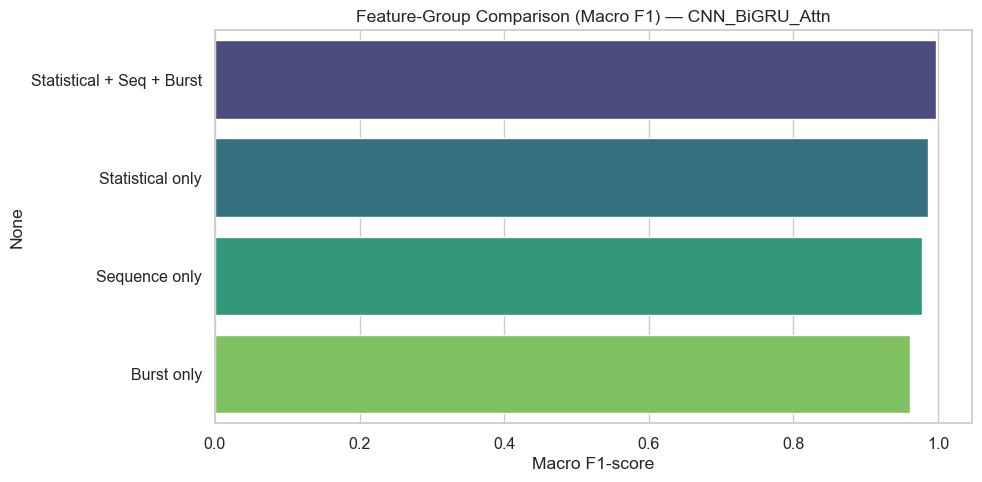

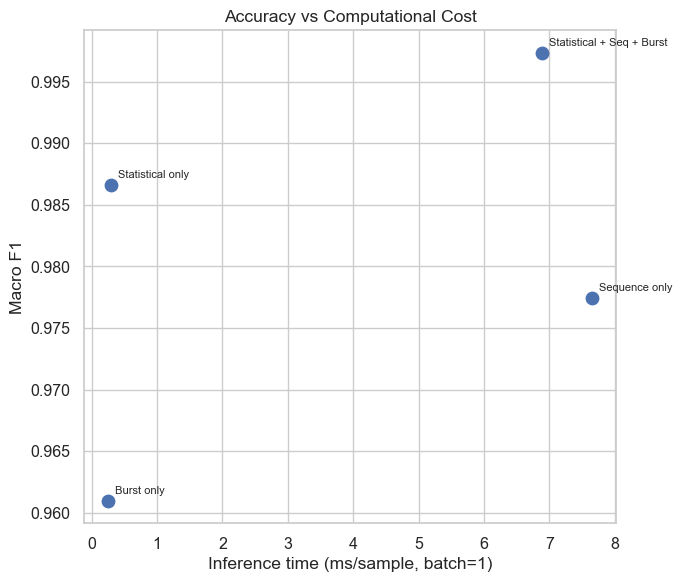

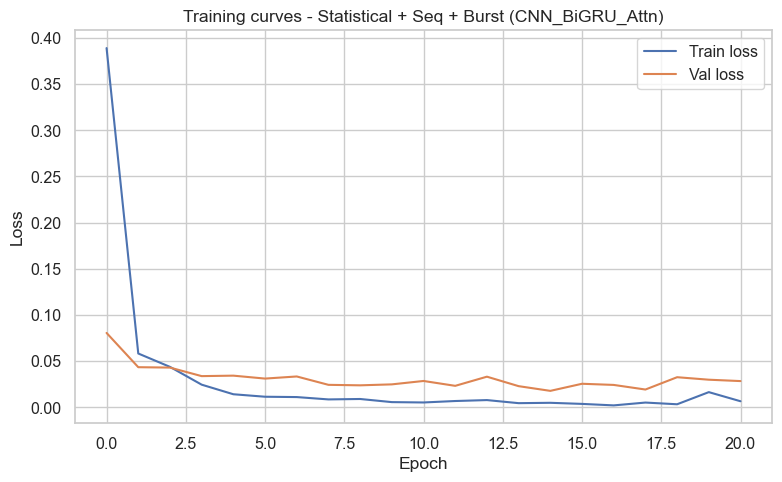

In [27]:
final_table = ablation_df.copy()
final_table = final_table.sort_values("f1", ascending=False)
print(final_table)

plt.figure(figsize=(10, 5))
order = final_table.index
sns.barplot(x=final_table["f1"].values, y=order, hue=order, palette="viridis", legend=False)
plt.xlabel("Macro F1-score")
plt.title(f"Feature-Group Comparison (Macro F1) — {BEST_ARCH}")
plt.tight_layout()
plt.savefig("f1_comparison.png", dpi=300)
plt.show()

plt.figure(figsize=(7, 6))
plt.scatter(final_table["inference_ms_per_sample"], final_table["f1"], s=80)
for name, row in final_table.iterrows():
    plt.annotate(name, (row["inference_ms_per_sample"], row["f1"]), fontsize=8, xytext=(5, 5), textcoords="offset points")
plt.xlabel("Inference time (ms/sample, batch=1)")
plt.ylabel("Macro F1")
plt.title("Accuracy vs Computational Cost")
plt.tight_layout()
plt.savefig("efficiency_tradeoff.png", dpi=300)
plt.show()

best_model_name = ablation_df["f1"].idxmax()
_, best_hist = train_with_early_stopping(
    MultiBranchNet(BEST_ARCH, X_stat_scaled.shape[1], X_burst_scaled.shape[1], n_classes,
                   branch_hidden=BEST_HIDDEN, dropout=BEST_DROPOUT,
                   **ablation_configs[best_model_name]),
    train_loader, val_loader, max_epochs=40, lr=BEST_LR, patience=6, verbose=False)

plt.figure(figsize=(8, 5))
plt.plot(best_hist["train_loss"], label="Train loss")
plt.plot(best_hist["val_loss"], label="Val loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title(f"Training curves - {best_model_name} ({BEST_ARCH})")
plt.legend(); plt.tight_layout()
plt.savefig("training_curves.png", dpi=300)
plt.show()

## 7. Cross-Validation

To verify that the reported performance of the final full-fusion model is not an artefact of a single train/test split, five-fold stratified cross-validation is performed, with mean and standard deviation reported across folds.

In [28]:
from sklearn.model_selection import StratifiedKFold

N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=32)

cv_results = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_seq_scaled, y), start=1):
    print(f"\nFold {fold}/{N_FOLDS}")

    tr_idx, va_idx = train_test_split(train_idx, test_size=0.15, stratify=y[train_idx], random_state=42)

    def subset_cv(idx):
        return X_seq_scaled[idx], X_stat_scaled[idx], X_burst_scaled[idx], y[idx]

    Xs_tr, Xt_tr, Xb_tr, y_tr = subset_cv(tr_idx)
    Xs_va, Xt_va, Xb_va, y_va = subset_cv(va_idx)
    Xs_te, Xt_te, Xb_te, y_te = subset_cv(test_idx)

    tr_ds = QUICMultiDataset(Xs_tr, Xt_tr, Xb_tr, y_tr)
    va_ds = QUICMultiDataset(Xs_va, Xt_va, Xb_va, y_va)
    te_ds = QUICMultiDataset(Xs_te, Xt_te, Xb_te, y_te)

    g = torch.Generator(); g.manual_seed(42)
    tr_loader = DataLoader(tr_ds, batch_size=BEST_BATCH, shuffle=True, generator=g)
    va_loader = DataLoader(va_ds, batch_size=BEST_BATCH, shuffle=False)
    te_loader = DataLoader(te_ds, batch_size=BEST_BATCH, shuffle=False)

    torch.manual_seed(42) 
    m = MultiBranchNet(BEST_ARCH, X_stat_scaled.shape[1], X_burst_scaled.shape[1], n_classes,
                        use_seq=True, use_stat=True, use_burst=True,
                        branch_hidden=BEST_HIDDEN, dropout=BEST_DROPOUT)
    m, _ = train_with_early_stopping(m, tr_loader, va_loader, max_epochs=40, lr=BEST_LR, patience=6, verbose=False)
    res = evaluate_model(m, te_loader, le.classes_, label=f"Fold {fold}", plot=False)
    cv_results.append(res)

cv_df = pd.DataFrame(cv_results)
print("\nCross-Validation Summary (Statistical + Seq + Burst, {} folds)".format(N_FOLDS))
print(cv_df[["accuracy", "precision", "recall", "f1"]])
print("\nMean +/- Std:")
for col in ["accuracy", "precision", "recall", "f1"]:
    print(f"  {col}: {cv_df[col].mean():.4f} +/- {cv_df[col].std():.4f}")


Fold 1/5
--- Fold 1 ---
Accuracy: 0.9961 | Precision: 0.9943 | Recall: 0.9945 | F1: 0.9944
Inference: 6.8402 ms/sample (batch=1) | Params: 32,918 | Size: 0.126 MB

Fold 2/5
--- Fold 2 ---
Accuracy: 0.9992 | Precision: 0.9994 | Recall: 0.9983 | F1: 0.9988
Inference: 6.9028 ms/sample (batch=1) | Params: 32,918 | Size: 0.126 MB

Fold 3/5
--- Fold 3 ---
Accuracy: 0.9969 | Precision: 0.9958 | Recall: 0.9940 | F1: 0.9949
Inference: 7.2156 ms/sample (batch=1) | Params: 32,918 | Size: 0.126 MB

Fold 4/5
--- Fold 4 ---
Accuracy: 0.9969 | Precision: 0.9941 | Recall: 0.9955 | F1: 0.9948
Inference: 6.5392 ms/sample (batch=1) | Params: 32,918 | Size: 0.126 MB

Fold 5/5
--- Fold 5 ---
Accuracy: 0.9953 | Precision: 0.9930 | Recall: 0.9949 | F1: 0.9939
Inference: 6.9347 ms/sample (batch=1) | Params: 32,918 | Size: 0.126 MB

Cross-Validation Summary (Statistical + Seq + Burst, 5 folds)
   accuracy  precision    recall        f1
0  0.996118   0.994342  0.994455  0.994397
1  0.999224   0.999390  0.99830

## 8. Model Interpretability

To examine which parts of a flow most influence the model's predictions, per-packet importance is computed for each correctly classified test flow: Grad-CAM is applied to the convolutional feature maps for TCN/ResNet1D encoders, while attention weights are used directly for the CNN-BiGRU-Attention encoder.

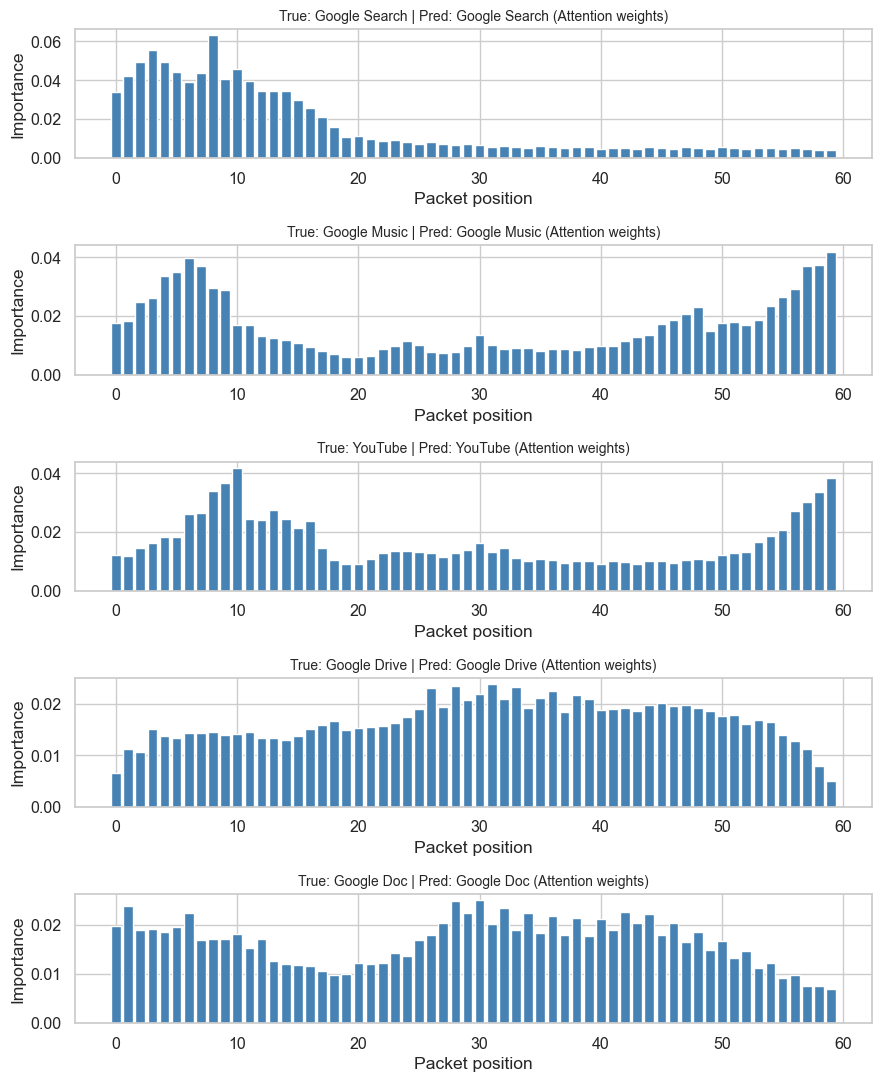

In [29]:
best_full_model = ablation_models["Statistical + Seq + Burst"]  
best_full_model.eval()

def get_attention_weights(model, x_seq, x_stat, x_burst):
    with torch.no_grad():
        _ = model(x_seq, x_stat, x_burst)
    return model.seq_encoder.last_attn_weights.squeeze(0).numpy()

sample_idx = []
seen_classes = set()
for i in idx_test:
    lbl = y[i]
    if lbl not in seen_classes:
        sample_idx.append(i)
        seen_classes.add(lbl)
    if len(seen_classes) == n_classes:
        break

fig, axes = plt.subplots(len(sample_idx), 1, figsize=(9, 2.2 * len(sample_idx)))
if len(sample_idx) == 1:
    axes = [axes]

for ax, idx in zip(axes, sample_idx):
    x_seq_i = torch.tensor(X_seq_scaled[idx:idx+1], dtype=torch.float32)
    x_stat_i = torch.tensor(X_stat_scaled[idx:idx+1], dtype=torch.float32)
    x_burst_i = torch.tensor(X_burst_scaled[idx:idx+1], dtype=torch.float32)
    true_label = le.classes_[y[idx]]

    with torch.no_grad():
        pred_logits = best_full_model(x_seq_i, x_stat_i, x_burst_i)
        pred_class = pred_logits.argmax(1).item()

    importance = get_attention_weights(best_full_model, x_seq_i, x_stat_i, x_burst_i)

    ax.bar(range(len(importance)), importance, color="steelblue")
    ax.set_title(f"True: {true_label} | Pred: {le.classes_[pred_class]} (Attention weights)", fontsize=10)
    ax.set_xlabel("Packet position")
    ax.set_ylabel("Importance")

plt.tight_layout()
plt.savefig("interpretability_per_class.png", dpi=300)
plt.show()

### 8.1 Class-Averaged Importance

Per-packet importance scores are averaged across all correctly classified test flows within each class, producing a representative profile of which packet positions most influence each class's predictions, rather than relying on a single illustrative example.

Flows used per class: {np.str_('Google Doc'): 183, np.str_('Google Drive'): 245, np.str_('Google Music'): 88, np.str_('Google Search'): 287, np.str_('YouTube'): 161}


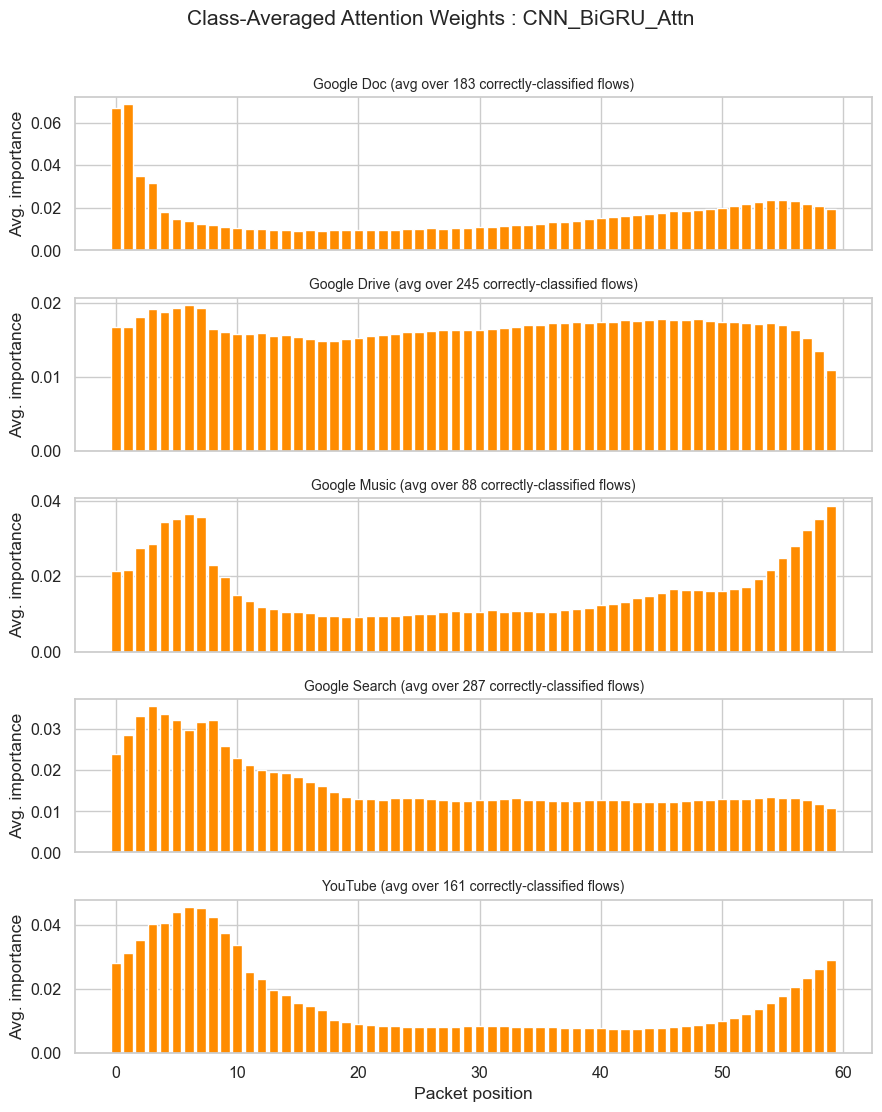


Most influential packet position per class:
  Google Doc: position 1 (importance=0.069)
  Google Drive: position 6 (importance=0.020)
  Google Music: position 59 (importance=0.039)
  Google Search: position 3 (importance=0.036)
  YouTube: position 6 (importance=0.046)


In [30]:
class_importance = {cls: [] for cls in le.classes_}

for idx in idx_test:
    x_seq_i = torch.tensor(X_seq_scaled[idx:idx+1], dtype=torch.float32)
    x_stat_i = torch.tensor(X_stat_scaled[idx:idx+1], dtype=torch.float32)
    x_burst_i = torch.tensor(X_burst_scaled[idx:idx+1], dtype=torch.float32)
    true_label = le.classes_[y[idx]]

    with torch.no_grad():
        pred_logits = best_full_model(x_seq_i, x_stat_i, x_burst_i)
        pred_class = pred_logits.argmax(1).item()

    if pred_class != y[idx]:
        continue  # only aggregate correctly-classified flows

    importance = get_attention_weights(best_full_model, x_seq_i, x_stat_i, x_burst_i)
    class_importance[true_label].append(importance)

avg_importance, n_used = {}, {}
for cls, arrs in class_importance.items():
    if len(arrs) == 0:
        print(f"WARNING: no correctly-classified test flows for class '{cls}'")
        continue
    stacked = np.stack(arrs)
    avg_importance[cls] = stacked.mean(axis=0)
    n_used[cls] = stacked.shape[0]

print("Flows used per class:", n_used)

fig, axes = plt.subplots(len(avg_importance), 1, figsize=(9, 2.2 * len(avg_importance)), sharex=True)
if len(avg_importance) == 1:
    axes = [axes]
for ax, (cls, imp) in zip(axes, avg_importance.items()):
    ax.bar(range(len(imp)), imp, color="darkorange")
    ax.set_title(f"{cls} (avg over {n_used[cls]} correctly-classified flows)", fontsize=10)
    ax.set_ylabel("Avg. importance")
axes[-1].set_xlabel("Packet position")
plt.suptitle(f"Class-Averaged Attention Weights : {BEST_ARCH}", y=1.01)
plt.tight_layout()
plt.savefig("interpretability_class_averaged.png", dpi=300)
plt.show()

print("\nMost influential packet position per class:")
for cls, imp in avg_importance.items():
    peak_pos = int(np.argmax(imp))
    print(f"  {cls}: position {peak_pos} (importance={imp[peak_pos]:.3f})")

## 9. Early (Partial-Flow) Classification

To evaluate suitability for real-time deployment, a capability claimed but not directly measured in prior QUIC classification literature, the pipeline is re-run using only the first K packets of each flow, for K = {5, 10, 15, 20, 30, 45}. All feature branches are recomputed from this truncated window, re-scaled using training-only statistics, and the fusion model is retrained at each K to ensure results reflect genuine differences in available signal rather than training variance.

In [31]:
def build_early_features(k):
    seq_list, stat_list, burst_list = [], [], []
    for f in flows:
        df_k = f["df"].iloc[:k].reset_index(drop=True)
        if len(df_k) < 2:
            df_k = f["df"].iloc[:2].reset_index(drop=True)
        seq_list.append(flow_to_sequence(df_k, max_len=k))
        stat_list.append(extract_statistical_features(df_k))
        burst_list.append(extract_burst_features(df_k))

    X_seq_k = np.stack(seq_list).astype(np.float32)
    X_stat_k = pd.DataFrame(stat_list).values.astype(np.float32)
    X_burst_k = pd.DataFrame(burst_list).values.astype(np.float32)
    return X_seq_k, X_stat_k, X_burst_k

print("Early-feature builder ready. Example shapes at K=10:")
xs, xt, xb = build_early_features(10)
print(xs.shape, xt.shape, xb.shape)

Early-feature builder ready. Example shapes at K=10:
(6439, 10, 4) (6439, 13) (6439, 17)



Early classification at K=5 packets
--- Fusion K=5 ---
Accuracy: 0.9669 | Precision: 0.9704 | Recall: 0.9554 | F1: 0.9619
Inference: 1.2337 ms/sample (batch=1) | Params: 32,918 | Size: 0.126 MB

Early classification at K=10 packets
--- Fusion K=10 ---
Accuracy: 0.9803 | Precision: 0.9816 | Recall: 0.9761 | F1: 0.9788
Inference: 2.2427 ms/sample (batch=1) | Params: 32,918 | Size: 0.126 MB

Early classification at K=15 packets
--- Fusion K=15 ---
Accuracy: 0.9834 | Precision: 0.9819 | Recall: 0.9790 | F1: 0.9803
Inference: 2.3504 ms/sample (batch=1) | Params: 32,918 | Size: 0.126 MB

Early classification at K=20 packets
--- Fusion K=20 ---
Accuracy: 0.9855 | Precision: 0.9850 | Recall: 0.9809 | F1: 0.9826
Inference: 2.7429 ms/sample (batch=1) | Params: 32,918 | Size: 0.126 MB

Early classification at K=30 packets
--- Fusion K=30 ---
Accuracy: 0.9803 | Precision: 0.9780 | Recall: 0.9714 | F1: 0.9744
Inference: 3.8961 ms/sample (batch=1) | Params: 32,918 | Size: 0.126 MB

Early classifica

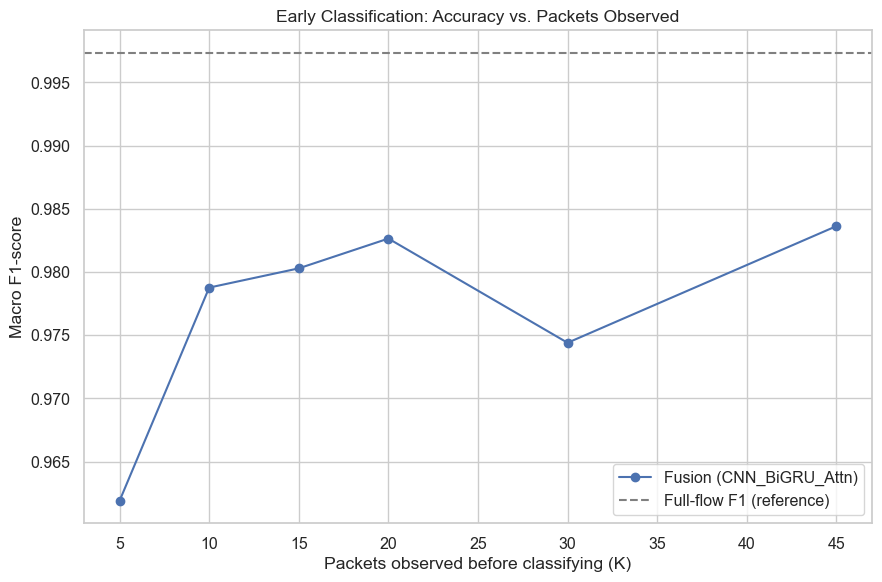

Reaches 95% of full-flow F1 (0.9475) at K = 5.0 packets


In [32]:
K_VALUES = [5, 10, 15, 20, 30, 45]
early_results = []
set_seed(32)
init_ref_model = MultiBranchNet(BEST_ARCH, X_stat_scaled.shape[1], X_burst_scaled.shape[1], n_classes,
                                  use_seq=True, use_stat=True, use_burst=True,
                                  branch_hidden=BEST_HIDDEN, dropout=BEST_DROPOUT)
initial_state = copy.deepcopy(init_ref_model.state_dict())

for K in K_VALUES:
    set_seed(32)
    print(f"\nEarly classification at K={K} packets")
    X_seq_k, X_stat_k, X_burst_k = build_early_features(K)
    n, t, c = X_seq_k.shape
    seq_sc_k = StandardScaler().fit(X_seq_k[idx_train].reshape(-1, c))
    X_seq_k_s = seq_sc_k.transform(X_seq_k.reshape(-1, c)).reshape(n, t, c).astype(np.float32)
    stat_sc_k = StandardScaler().fit(X_stat_k[idx_train])
    X_stat_k_s = stat_sc_k.transform(X_stat_k).astype(np.float32)
    burst_sc_k = StandardScaler().fit(X_burst_k[idx_train])
    X_burst_k_s = burst_sc_k.transform(X_burst_k).astype(np.float32)

    def subset_k(idx):
        return X_seq_k_s[idx], X_stat_k_s[idx], X_burst_k_s[idx], y[idx]

    Xs_tr, Xt_tr, Xb_tr, y_tr = subset_k(idx_train)
    Xs_va, Xt_va, Xb_va, y_va = subset_k(idx_val)
    Xs_te, Xt_te, Xb_te, y_te = subset_k(idx_test)

    tr_ds = QUICMultiDataset(Xs_tr, Xt_tr, Xb_tr, y_tr)
    va_ds = QUICMultiDataset(Xs_va, Xt_va, Xb_va, y_va)
    te_ds = QUICMultiDataset(Xs_te, Xt_te, Xb_te, y_te)

    g = torch.Generator(); g.manual_seed(32)
    tr_loader = DataLoader(tr_ds, batch_size=BEST_BATCH, shuffle=True, generator=g)
    va_loader = DataLoader(va_ds, batch_size=BEST_BATCH, shuffle=False)
    te_loader = DataLoader(te_ds, batch_size=BEST_BATCH, shuffle=False)

    m = MultiBranchNet(BEST_ARCH, X_stat_k_s.shape[1], X_burst_k_s.shape[1], n_classes,
                        use_seq=True, use_stat=True, use_burst=True,
                        branch_hidden=BEST_HIDDEN, dropout=BEST_DROPOUT)
    m.load_state_dict(initial_state)  
    m, _ = train_with_early_stopping(m, tr_loader, va_loader, max_epochs=40, lr=BEST_LR, patience=8, verbose=False)
    res_nn = evaluate_model(m, te_loader, le.classes_, label=f"Fusion K={K}", plot=False)

    early_results.append({
        "K": K,
        "fusion_acc": res_nn["accuracy"],
        "fusion_precision": res_nn["precision"],
        "fusion_recall": res_nn["recall"],
        "fusion_f1": res_nn["f1"],
    })

early_df = pd.DataFrame(early_results)
print("\nEarly Classification Results")
print(early_df)

full_flow_f1 = ablation_df.loc["Statistical + Seq + Burst", "f1"]
plt.figure(figsize=(9, 6))
plt.plot(early_df["K"], early_df["fusion_f1"], marker="o", label=f"Fusion ({BEST_ARCH})")
plt.axhline(full_flow_f1, color="gray", linestyle="--", label="Full-flow F1 (reference)")
plt.xlabel("Packets observed before classifying (K)")
plt.ylabel("Macro F1-score")
plt.title("Early Classification: Accuracy vs. Packets Observed")
plt.legend()
plt.tight_layout()
plt.savefig("early_classification_curve.png", dpi=300)
plt.show()

target = 0.95 * full_flow_f1
hit = early_df[early_df["fusion_f1"] >= target]
if len(hit):
    print(f"Reaches 95% of full-flow F1 ({target:.4f}) at K = {hit.iloc[0]['K']} packets")
else:
    print("Did not reach 95% of full-flow F1 within tested K range.")

## 10. Conclusion

This project developed and evaluated a multi-branch deep learning framework for classifying encrypted QUIC traffic using only packet-level metadata. Combining statistical, burst-based, and sequence-based features through fusion allowed flows from five Google services to be classified with a macro F1 score of 99.73% on the held-out test set, confirmed via five-fold cross-validation (mean F1 = 99.54%, std = 0.20%).

The architecture comparison found the CNN-BiGRU-Attention encoder performed best, though all three architectures scored within a narrow range, suggesting the choice of feature branches mattered more than the choice of sequence encoder. This is reinforced by the ablation study: each branch alone achieved 96 to 98.6% F1, meaning fusion's improvement, while consistent, was comparatively modest.

The early-classification experiment showed the model retains over 95% of its full-flow performance using only the first five packets, with further gains from additional packets becoming increasingly marginal. Interpretability analysis via Grad-CAM and attention weights showed different services exhibit distinct temporal signatures, some identifiable within the first few packets, others only later in the flow, providing a plausible explanation for the early-classification results.